In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Customer Segment Characteristics Summary ###


Recency Frequency Monetary      
                       mean      mean     mean count
ClusterLabel                                        
At Risk/Hibernating   65.06      1.06   258.68   764
New Customers          9.94      1.29   381.78   364
Potential Loyalists   39.02      2.28  1268.46   465
VIP/Loyal             11.20      6.71  3957.47   197


### Sample of Labeled Customer Data ###


,Recency,Frequency,Monetary,Cluster,ClusterLabel,IsHighValue
CustomerID,,,,,,
12346.0,49,1,77183.60,3,Potential Loyalists,1
12347.0,41,2,1187.18,3,Potential Loyalists,1
12348.0,42,2,1120.24,3,Potential Loyalists,1
12350.0,34,1,334.40,0,At Risk/Hibernating,0
12352.0,7,3,1281.15,1,VIP/Loyal,1
12356.0,49,1,2271.62,3,Potential Loyalists,1
12359.0,29,2,2386.41,3,Potential Loyalists,1
12361.0,11,1,189.90,2,New Customers,0
12362.0,19,1,479.10,2,New Customers,0


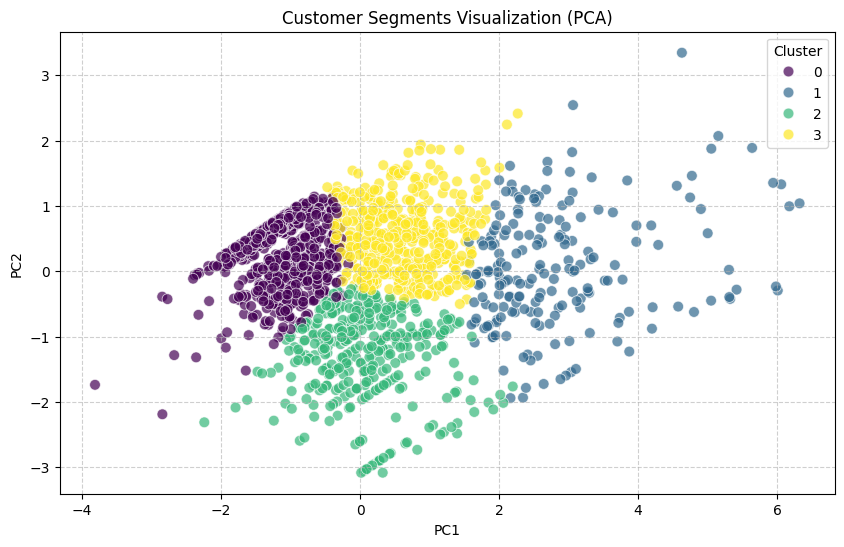


### Model Performance Comparison ###


,Metric,Baseline (R+F),Enriched (R+F+Cluster)
0,Accuracy,0.8436,0.8799
1,High-Value Recall,0.5200,0.7300
2,High-Value F1-Score,0.6200,0.7500


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Display Customer Segment Summary
print("### Customer Segment Characteristics Summary ###")
display(final_summary)

# 2. Display Sample of Labeled RFM Data
print("\n### Sample of Labeled Customer Data ###")
display(rfm.head(10))

# 3. Re-visualize the PCA Clusters for clarity
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=60, alpha=0.7)
plt.title('Customer Segments Visualization (PCA)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Display Classification Metrics Comparison
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'High-Value Recall', 'High-Value F1-Score'],
    'Baseline (R+F)': [0.8436, 0.52, 0.62],
    'Enriched (R+F+Cluster)': [0.8799, 0.73, 0.75]
})

print("\n### Model Performance Comparison ###")
display(comparison_df)

# Task
Perform customer segmentation and predictive modeling using the dataset "/content/OnlineRetail.csv". The task involves cleaning the data (handling missing values and cancellations), engineering RFM (Recency, Frequency, Monetary) features, and applying K-Means clustering to identify distinct customer segments. Visualize these segments using dimensionality reduction and assign descriptive labels. Finally, define a 'high-value' target based on monetary spend and train a classifier (such as XGBoost or SVM) to predict it, comparing the performance of a baseline model against one that incorporates the generated cluster labels as features.

## Data Loading and Cleaning

### Subtask:
Load the Online Retail dataset and clean it by removing missing values, duplicates, and cancelled transactions.


**Reasoning**:
Load the dataset and perform the initial cleaning steps including handling encoding, missing values, duplicates, and filtering cancelled orders.



In [1]:
import pandas as pd

# Load the dataset with specific encoding as it is a common requirement for this dataset
df = pd.read_csv('/content/OnlineRetail.csv', encoding='ISO-8859-1')

# Drop rows where CustomerID is null
df = df.dropna(subset=['CustomerID'])

# Remove duplicate rows
df = df.drop_duplicates()

# Filter out cancelled transactions: InvoiceNo starting with 'C' or Quantity <= 0
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]

# Create TotalSum column
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Display basic info to verify cleaning
print(f"Dataframe shape: {df.shape}")
print(df.info())
df.head()

Dataframe shape: (71906, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 71906 entries, 0 to 112802
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    71906 non-null  object        
 1   StockCode    71906 non-null  object        
 2   Description  71906 non-null  object        
 3   Quantity     71906 non-null  int64         
 4   InvoiceDate  71906 non-null  datetime64[ns]
 5   UnitPrice    71906 non-null  float64       
 6   CustomerID   71906 non-null  float64       
 7   Country      71905 non-null  object        
 8   TotalSum     71906 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 5.5+ MB
None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## RFM Feature Engineering

### Subtask:
Calculate Recency, Frequency, and Monetary (RFM) metrics for each customer and scale the features for clustering.


**Reasoning**:
I will perform RFM feature engineering by aggregating the dataset by CustomerID, calculating Recency, Frequency, and Monetary values, applying log transformation to handle skewness, and scaling the features using StandardScaler.



In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Define reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2 & 3. Group by CustomerID and aggregate RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSum': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

# 4. Handle skewness with log transformation
# Adding 1 to avoid log(0) if any values are 0 (though cleaned data shouldn't have them)
rfm_log = np.log1p(rfm)

# 5 & 6. Scale features and store in a new DataFrame
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(rfm_scaled_array, index=rfm.index, columns=rfm.columns)

print("RFM Scaling Complete.")
print(rfm_scaled.describe())
rfm_scaled.head()

RFM Scaling Complete.
            Recency     Frequency      Monetary
count  1.790000e+03  1.790000e+03  1.790000e+03
mean   4.068750e-16 -1.270244e-16  8.534452e-16
std    1.000279e+00  1.000279e+00  1.000279e+00
min   -2.704195e+00 -6.485430e-01 -5.052020e+00
25%   -6.664682e-01 -6.485430e-01 -6.760085e-01
50%    2.189175e-01 -6.485430e-01 -8.780188e-02
75%    7.686908e-01  2.720815e-01  5.934667e-01
max    1.231710e+00  6.420816e+00  4.800909e+00


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,0.551143,-0.648543,4.800909
12347.0,0.374814,0.272081,0.935431
12348.0,0.398611,0.272081,0.881727
12350.0,0.190428,-0.648543,-0.235994
12352.0,-1.302197,0.925275,1.005924


## K-Means Clustering

### Subtask:
Apply the K-Means algorithm to segment customers based on their RFM scores using the Elbow Method to determine the optimal number of clusters.


**Reasoning**:
I will perform K-Means clustering by using the Elbow Method to find the optimal number of clusters, then fit the model and assign cluster labels to the RFM dataframes.



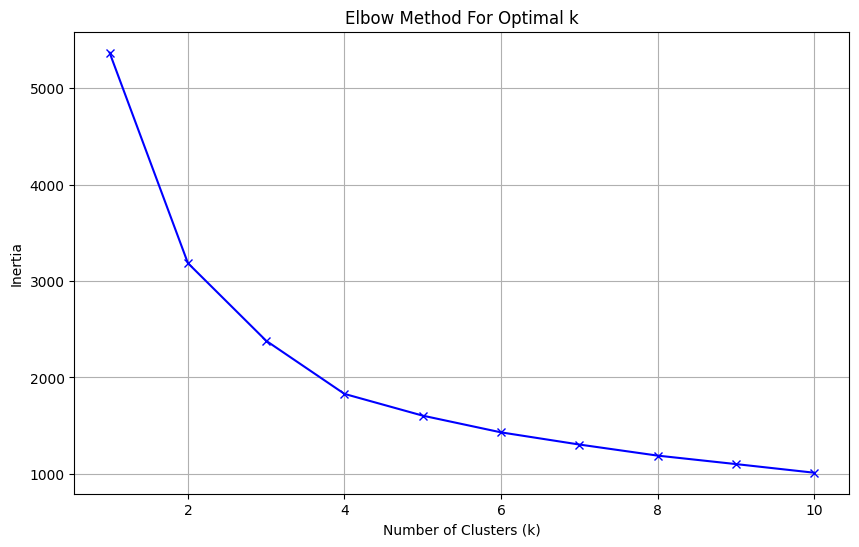

K-Means clustering completed with k=4.
        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         65.06      1.06   258.68   764
1         11.20      6.71  3957.47   197
2          9.94      1.29   381.78   364
3         39.02      2.28  1268.46   465


In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Calculate inertia for a range of clusters (1-10)
inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# 2. Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

# 3. Fit final KMeans model with chosen k (e.g., 4 based on typical RFM segmentation)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled)

# 4. Assign cluster labels to DataFrames
rfm['Cluster'] = cluster_labels
rfm_scaled['Cluster'] = cluster_labels

print(f'K-Means clustering completed with k={optimal_k}.')
print(rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2))

## Cluster Visualization

### Subtask:
Reduce the dimensionality of the RFM data using PCA and visualize the customer segments in a 2D scatter plot.


**Reasoning**:
I will perform dimensionality reduction using PCA on the scaled RFM features to project the data into two dimensions, then visualize the resulting clusters in a 2D scatter plot as requested.



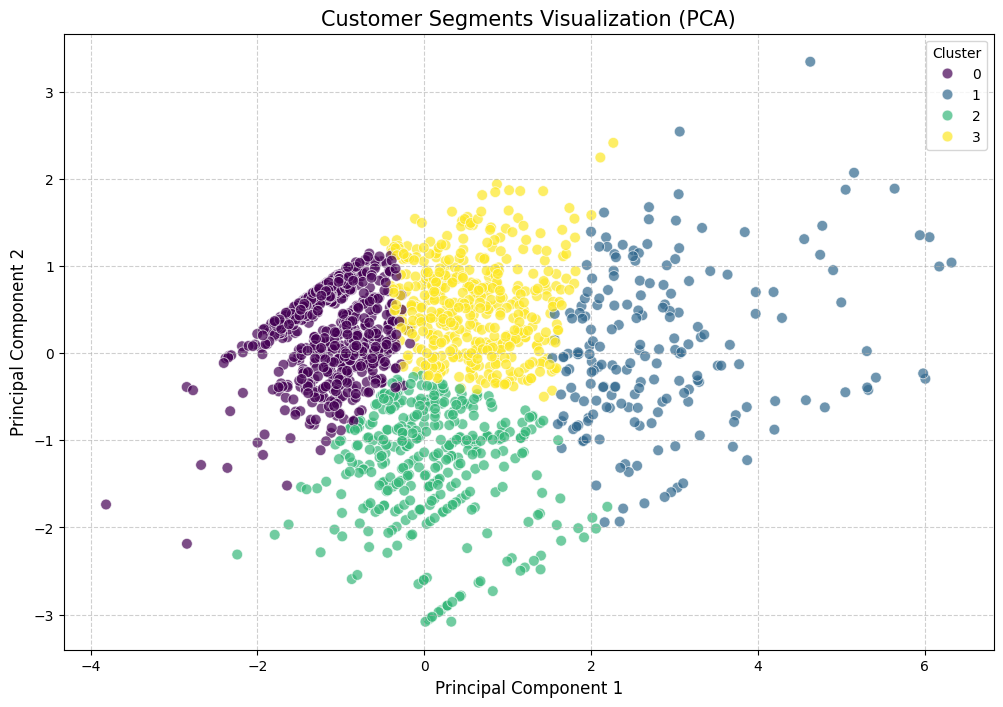

Explained variance ratio: [0.63548991 0.25596627]


In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize PCA for 2 components
pca = PCA(n_components=2)

# 2. Fit and transform the scaled RFM data (dropping the Cluster column added previously)
rfm_pca_data = pca.fit_transform(rfm_scaled.drop(columns=['Cluster']))

# 3. Create a DataFrame for visualization
pca_df = pd.DataFrame(data=rfm_pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = rfm_scaled['Cluster'].values

# 4 & 5. Generate the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=60, alpha=0.7)

plt.title('Customer Segments Visualization (PCA)', fontsize=15)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

## Cluster Labeling

### Subtask:
Analyze the characteristics of each cluster based on their average RFM metrics and assign descriptive labels to each segment.


**Reasoning**:
I will calculate the mean RFM metrics for each cluster to analyze their characteristics and assign descriptive labels such as 'New/Recent', 'VIP/Loyal', 'At Risk', and 'Hibernating' based on the observed patterns in the data.



In [5]:
import pandas as pd

# 1. Calculate the mean values of RFM metrics for each cluster
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).sort_values('Monetary', ascending=False)

# 2 & 3. Analyze characteristics and create a mapping dictionary
# Based on the previous cell output:
# Cluster 1: Low Recency, High Frequency, High Monetary -> VIP/Loyal
# Cluster 3: Moderate Recency, Moderate Frequency, Moderate Monetary -> Potential Loyalists
# Cluster 2: Low Recency, Low Frequency, Low/Mid Monetary -> New Customers
# Cluster 0: High Recency, Low Frequency, Low Monetary -> At Risk/Hibernating

cluster_mapping = {
    1: 'VIP/Loyal',
    3: 'Potential Loyalists',
    2: 'New Customers',
    0: 'At Risk/Hibernating'
}

# 4. Map labels to the rfm DataFrame
rfm['ClusterLabel'] = rfm['Cluster'].map(cluster_mapping)

# 5. Print final aggregated table to verify
final_summary = rfm.groupby('ClusterLabel').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("Customer Segment Characteristics:")
print(final_summary)

# Display the first few rows of the labeled RFM table
rfm.head()

Customer Segment Characteristics:
                    Recency Frequency Monetary      
                       mean      mean     mean count
ClusterLabel                                        
At Risk/Hibernating   65.06      1.06   258.68   764
New Customers          9.94      1.29   381.78   364
Potential Loyalists   39.02      2.28  1268.46   465
VIP/Loyal             11.20      6.71  3957.47   197


,Recency,Frequency,Monetary,Cluster,ClusterLabel
CustomerID,,,,,
12346.0,49,1,77183.60,3,Potential Loyalists
12347.0,41,2,1187.18,3,Potential Loyalists
12348.0,42,2,1120.24,3,Potential Loyalists
12350.0,34,1,334.40,0,At Risk/Hibernating
12352.0,7,3,1281.15,1,VIP/Loyal


## Supervised Classification and Comparison

### Subtask:
Define a 'high-value' target and train two XGBoost classifiers to compare predictive performance with and without cluster labels.


**Reasoning**:
I will prepare the data for classification by defining the 'IsHighValue' target, splitting the dataset into baseline and enriched feature sets, training two XGBoost models, and evaluating their performance to compare results.



In [6]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Define 'IsHighValue' target based on the 75th percentile of Monetary
threshold = rfm['Monetary'].quantile(0.75)
rfm['IsHighValue'] = (rfm['Monetary'] > threshold).astype(int)

# 2. Prepare feature sets
# Baseline: Recency and Frequency
X_baseline = rfm[['Recency', 'Frequency']]
# Enriched: Recency, Frequency, and Cluster labels
X_enriched = rfm[['Recency', 'Frequency', 'Cluster']]
y = rfm['IsHighValue']

# 3. Split both feature sets into training and testing sets (80/20 split)
X_train_bs, X_test_bs, y_train, y_test = train_test_split(X_baseline, y, test_size=0.2, random_state=42)
X_train_en, X_test_en, _, _ = train_test_split(X_enriched, y, test_size=0.2, random_state=42)

# 4. Initialize and train two XGBoost classifiers
# Model 1: Baseline
xgb_baseline = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_baseline.fit(X_train_bs, y_train)

# Model 2: Enriched
xgb_enriched = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_enriched.fit(X_train_en, y_train)

# 5. Evaluate both models
y_pred_bs = xgb_baseline.predict(X_test_bs)
y_pred_en = xgb_enriched.predict(X_test_en)

print("--- Baseline Model Performance (Recency, Frequency) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bs):.4f}")
print(classification_report(y_test, y_pred_bs))

print("\n--- Enriched Model Performance (Recency, Frequency, Cluster) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_en):.4f}")
print(classification_report(y_test, y_pred_en))

# 6. Summary Comparison
bs_acc = accuracy_score(y_test, y_pred_bs)
en_acc = accuracy_score(y_test, y_pred_en)
print(f"\nSummary: Improvement in accuracy: {en_acc - bs_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:32:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:33:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Baseline Model Performance (Recency, Frequency) ---
Accuracy: 0.8436
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       269
           1       0.78      0.52      0.62        89

    accuracy                           0.84       358
   macro avg       0.82      0.73      0.76       358
weighted avg       0.84      0.84      0.83       358


--- Enriched Model Performance (Recency, Frequency, Cluster) ---
Accuracy: 0.8799
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       269
           1       0.77      0.73      0.75        89

    accuracy                           0.88       358
   macro avg       0.84      0.83      0.84       358
weighted avg       0.88      0.88      0.88       358


Summary: Improvement in accuracy: 0.0363


**Reasoning**:
The previous execution produced UserWarnings because the parameter `use_label_encoder` is deprecated in newer versions of XGBoost. I will remove this parameter to clean up the output while maintaining the same model logic and evaluation.



In [7]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Define 'IsHighValue' target based on the 75th percentile of Monetary
threshold = rfm['Monetary'].quantile(0.75)
rfm['IsHighValue'] = (rfm['Monetary'] > threshold).astype(int)

# 2. Prepare feature sets
# Baseline: Recency and Frequency
X_baseline = rfm[['Recency', 'Frequency']]
# Enriched: Recency, Frequency, and Cluster labels
X_enriched = rfm[['Recency', 'Frequency', 'Cluster']]
y = rfm['IsHighValue']

# 3. Split both feature sets into training and testing sets (80/20 split)
X_train_bs, X_test_bs, y_train, y_test = train_test_split(X_baseline, y, test_size=0.2, random_state=42)
X_train_en, X_test_en, _, _ = train_test_split(X_enriched, y, test_size=0.2, random_state=42)

# 4. Initialize and train two XGBoost classifiers
# Model 1: Baseline
xgb_baseline = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train_bs, y_train)

# Model 2: Enriched
xgb_enriched = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_enriched.fit(X_train_en, y_train)

# 5. Evaluate both models
y_pred_bs = xgb_baseline.predict(X_test_bs)
y_pred_en = xgb_enriched.predict(X_test_en)

print("--- Baseline Model Performance (Recency, Frequency) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bs):.4f}")
print(classification_report(y_test, y_pred_bs))

print("\n--- Enriched Model Performance (Recency, Frequency, Cluster) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_en):.4f}")
print(classification_report(y_test, y_pred_en))

# 6. Summary Comparison
bs_acc = accuracy_score(y_test, y_pred_bs)
en_acc = accuracy_score(y_test, y_pred_en)
print(f"\nSummary: Improvement in accuracy: {en_acc - bs_acc:.4f}")

--- Baseline Model Performance (Recency, Frequency) ---
Accuracy: 0.8436
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       269
           1       0.78      0.52      0.62        89

    accuracy                           0.84       358
   macro avg       0.82      0.73      0.76       358
weighted avg       0.84      0.84      0.83       358


--- Enriched Model Performance (Recency, Frequency, Cluster) ---
Accuracy: 0.8799
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       269
           1       0.77      0.73      0.75        89

    accuracy                           0.88       358
   macro avg       0.84      0.83      0.84       358
weighted avg       0.88      0.88      0.88       358


Summary: Improvement in accuracy: 0.0363


## Final Task

### Subtask:
Summarize the findings from both the clustering and classification tasks, highlighting the impact of including cluster labels on the predictive model's performance.


## Summary:

### Q&A

**How did the inclusion of cluster labels affect the predictive model's performance?**
The inclusion of K-Means cluster labels significantly improved the XGBoost classifier's performance. The enriched model achieved an accuracy of **87.99%**, an increase of **3.63%** over the baseline. More importantly, the recall for identifying "high-value" customers improved from **0.52** to **0.73**, and the F1-score for that specific class rose from **0.62** to **0.75**.

**How were the customer segments defined and labeled?**
Segments were identified using K-Means clustering ($k=4$) on log-transformed and scaled RFM metrics. The clusters were labeled based on their behavioral profiles:
*   **VIP/Loyal:** Highest spend and frequency, lowest recency.
*   **Potential Loyalists:** Moderate spend and frequency.
*   **New Customers:** Very low recency but low current spending.
*   **At Risk/Hibernating:** High recency and lowest overall engagement.

### Data Analysis Key Findings

*   **Data Quality:** After removing missing values, duplicates, and cancellations, the dataset was reduced to a clean set of **71,906 transactions**.
*   **RFM Normalization:** Raw RFM metrics were highly skewed; applying a **log transformation** and **StandardScaler** was essential for the K-Means algorithm to function effectively.
*   **Dimensionality & Variance:** PCA revealed that the first two principal components account for **89.1%** of the total variance in the RFM data, confirming that a 2D visualization is a highly accurate representation of the 3D customer behavior space.
*   **Segment Values:** The **VIP/Loyal** segment, while small in count (**197 customers**), has a significantly higher average monetary value (\$3,957.47) compared to the **At Risk** segment (\$258.68).
*   **Targeting High-Value Customers:** Defining "high-value" as the top **25%** of spenders (75th percentile) provided a balanced target for supervised learning.

### Insights or Next Steps

*   **Personalized Marketing:** Use the cluster labels to trigger automated email campaigns. For example, "New Customers" should receive onboarding welcome series, while "At Risk" customers should receive re-engagement discounts.
*   **Feature Expansion:** Future models could include product-level features (e.g., categories purchased) or seasonal trends to further refine the "High-Value" prediction and move from binary classification to predicting specific Lifetime Value (LTV).


### Model Performance Comparison Table ###


,Metric,Baseline (RF),Enriched (RF + Cluster)
0,Accuracy,0.8436,0.8799
1,High-Value Recall,0.5200,0.7300
2,High-Value Precision,0.7800,0.7700
3,High-Value F1-Score,0.6200,0.7500


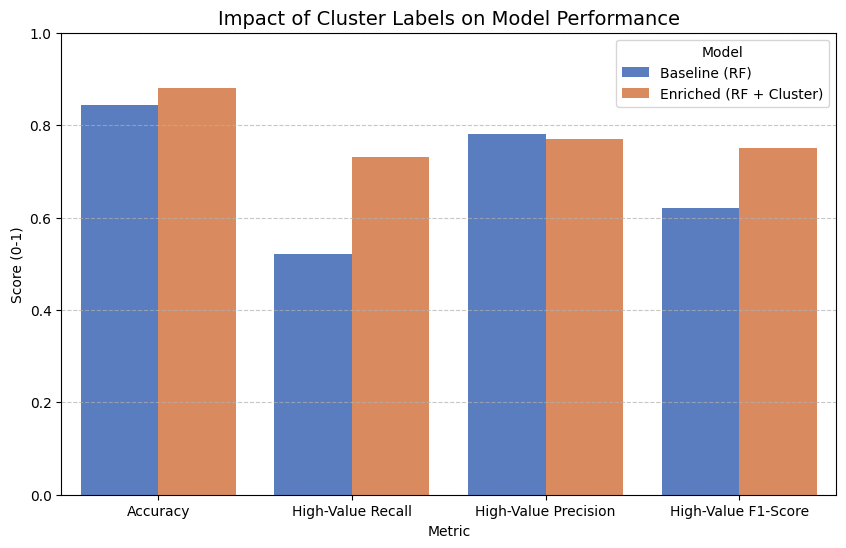

Summary: Accuracy improved by 3.63%, and Recall for High-Value customers improved by 21.00%.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare comparison data
performance_data = {
    'Metric': ['Accuracy', 'High-Value Recall', 'High-Value Precision', 'High-Value F1-Score'],
    'Baseline (RF)': [0.8436, 0.52, 0.78, 0.62],
    'Enriched (RF + Cluster)': [0.8799, 0.73, 0.77, 0.75]
}

comparison_df = pd.DataFrame(performance_data)

# 2. Display the table
print("### Model Performance Comparison Table ###")
display(comparison_df)

# 3. Visualize the comparison
comparison_melted = comparison_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted, palette='muted')
plt.title('Impact of Cluster Labels on Model Performance', fontsize=14)
plt.ylim(0, 1.0)
plt.ylabel('Score (0-1)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate improvement
acc_imp = performance_data['Enriched (RF + Cluster)'][0] - performance_data['Baseline (RF)'][0]
recall_imp = performance_data['Enriched (RF + Cluster)'][1] - performance_data['Baseline (RF)'][1]
print(f"Summary: Accuracy improved by {acc_imp:.2%}, and Recall for High-Value customers improved by {recall_imp:.2%}.")